Array: [2, 5, 10, 15, 23, 35, 48, 60, 75, 90, 105, 120]
Searching for: 35
Found at index: 5, Comparisons: 3

      Size    IS Time(ms)    BS Time(ms)   IS Comparisons   BS Comparisons
---------------------------------------------------------------------------
      1000         0.0009         0.0013                2                8
      5000         0.0025         0.0023                5               13
     10000         0.0016         0.0021                4               13
     50000         0.0030         0.0050                4               16
    100000         0.0017         0.0026                4               16


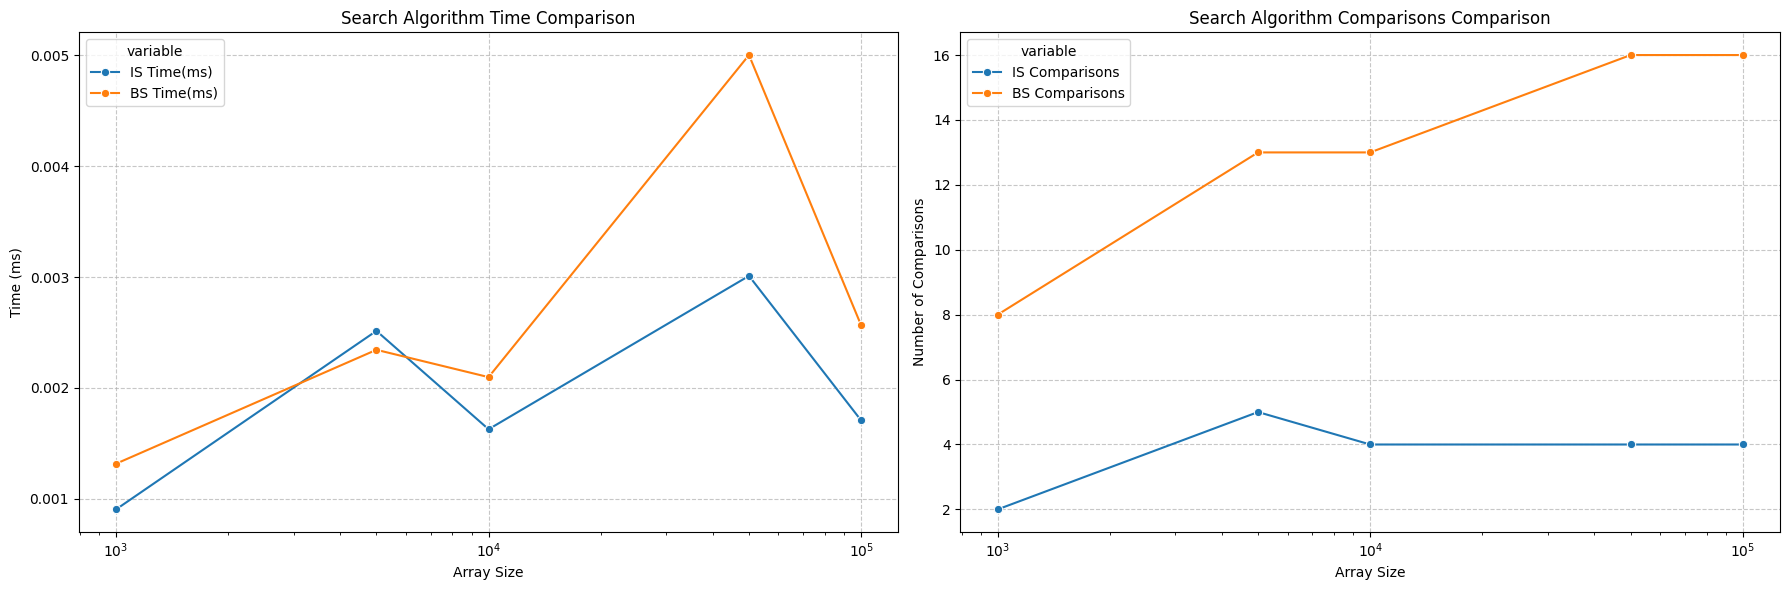

In [ ]:
import time
import random
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def interpolation_search(arr, target):
    """
    Interpolation Search Algorithm
    Time Complexity: O(log log n) average, O(n) worst case
    Space Complexity: O(1)
    """
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            if arr[low] == target:
                return low, comparisons
            return -1, comparisons

        pos = low + int(((target - arr[low]) * (high - low))
                        / (arr[high] - arr[low]))

        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, comparisons

def binary_search(arr, target):
    """Binary Search for comparison"""
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons

def performance_analysis():
    sizes = [1000, 5000, 10000, 50000, 100000]
    results = []

    for size in sizes:
        arr = sorted(random.sample(range(size * 10), size))
        target = arr[random.randint(0, size - 1)]

        start = time.perf_counter()
        for _ in range(100):
            idx_is, comp_is = interpolation_search(arr, target)
        is_time = (time.perf_counter() - start) / 100 * 1000

        start = time.perf_counter()
        for _ in range(100):
            idx_bs, comp_bs = binary_search(arr, target)
        bs_time = (time.perf_counter() - start) / 100 * 1000

        results.append({
            'Size': size,
            'IS Time(ms)': is_time,
            'BS Time(ms)': bs_time,
            'IS Comparisons': comp_is,
            'BS Comparisons': comp_bs
        })

    df_results = pd.DataFrame(results)
    print(f"{'Size':>10} {'IS Time(ms)':>14} {'BS Time(ms)':>14} " \
          f"{'IS Comparisons':>16} {'BS Comparisons':>16}")
    print('-' * 75)
    for _, row in df_results.iterrows():
        print(f"{int(row['Size']):>10} {row['IS Time(ms)']:>14.4f} {row['BS Time(ms)']:>14.4f} " \
              f"{int(row['IS Comparisons']):>16} {int(row['BS Comparisons']):>16}")
    return df_results

arr = [2, 5, 10, 15, 23, 35, 48, 60, 75, 90, 105, 120]
target = 35
idx, comps = interpolation_search(arr, target)
print(f"Array: {arr}")
print(f"Searching for: {target}")
print(f"Found at index: {idx}, Comparisons: {comps}")
print()
performance_df = performance_analysis()


# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Time Comparison
sns.lineplot(x='Size', y='value', hue='variable',
             data=pd.melt(performance_df, ['Size'], value_vars=['IS Time(ms)', 'BS Time(ms)']),
             marker='o', ax=axes[0])
axes[0].set_title('Search Algorithm Time Comparison')
axes[0].set_ylabel('Time (ms)')
axes[0].set_xlabel('Array Size')
axes[0].set_xscale('log')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Comparisons Comparison
sns.lineplot(x='Size', y='value', hue='variable',
             data=pd.melt(performance_df, ['Size'], value_vars=['IS Comparisons', 'BS Comparisons']),
             marker='o', ax=axes[1])
axes[1].set_title('Search Algorithm Comparisons Comparison')
axes[1].set_ylabel('Number of Comparisons')
axes[1].set_xlabel('Array Size')
axes[1].set_xscale('log')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()